# The magic dataset

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

In [20]:
# On importe le datset
names = ["fLength", "fWidth", "fSize", "fConc", "fConc1", "fAsym", "fM3Long", "fM3Trans", "fAlpha", "fDist", "class"]
df = pd.read_csv("data/magic04.data", names = names)

In [21]:
# On convertis les classes g et h en classes binaires (0 et 1)
df["class"] = (df["class"] == "g").astype(int)

In [22]:
#maintenant g = 1 et h = 0
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


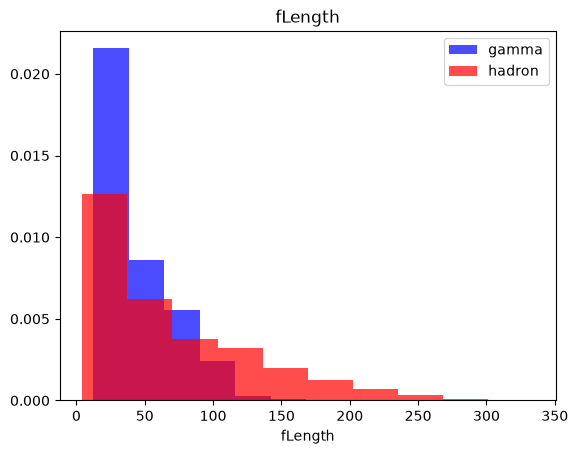

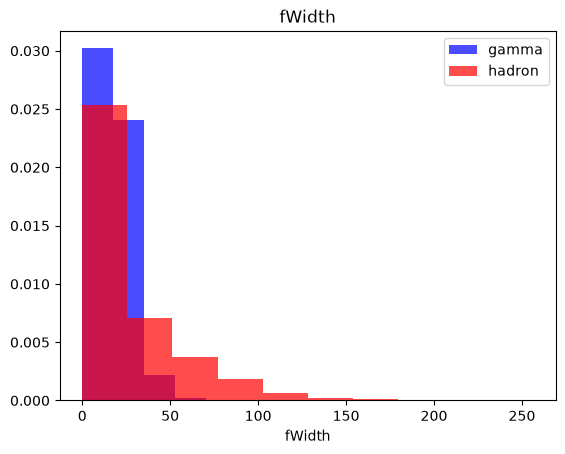

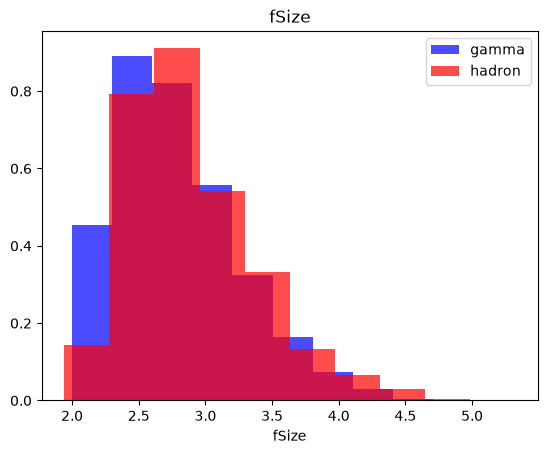

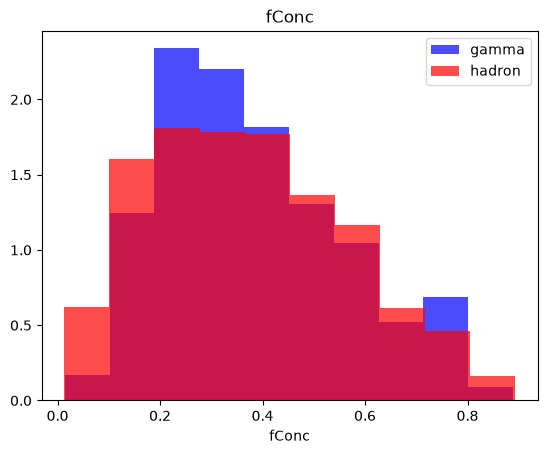

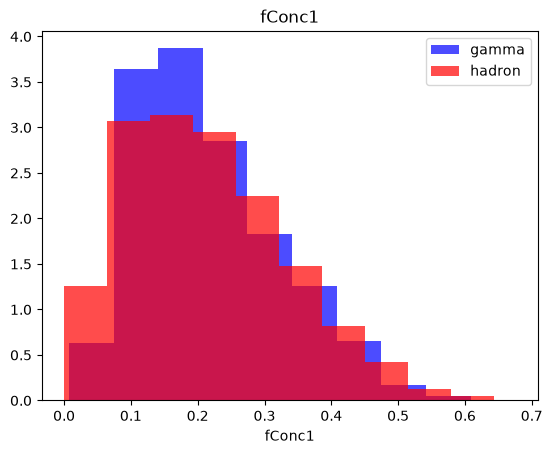

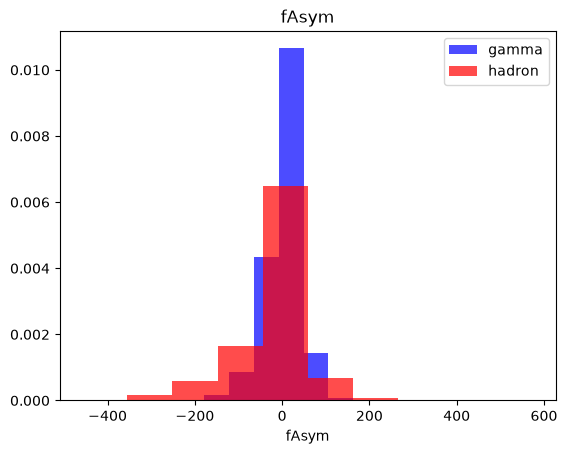

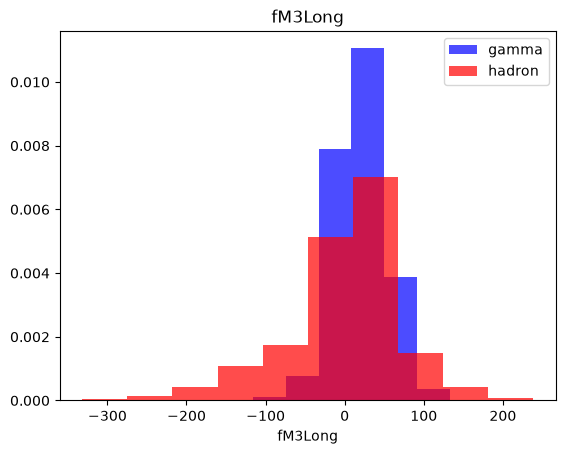

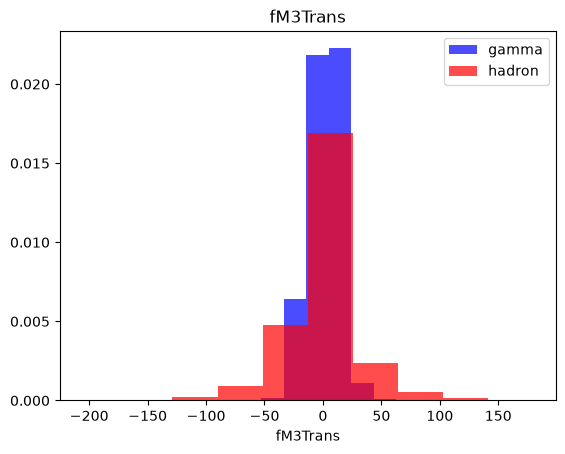

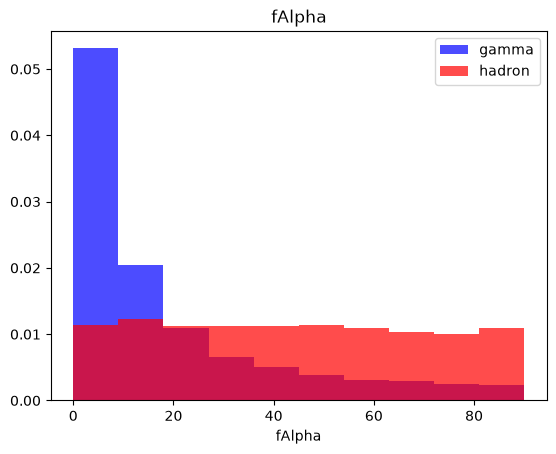

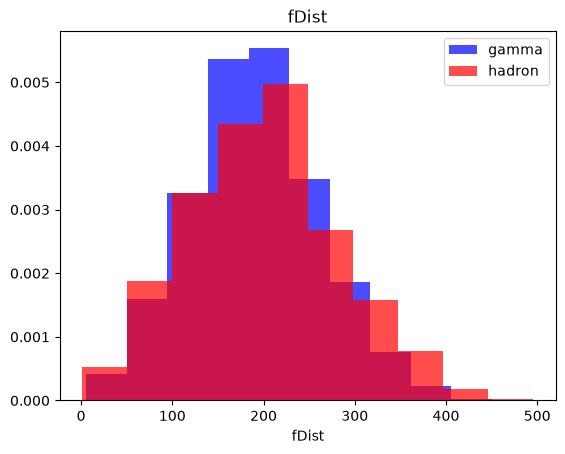

In [23]:
#regardons la distribution des features en fonction de la classe grâce a ça
for label in names[:-1]:
    plt.hist(df[df["class"] == 1][label], color = "blue", label = "gamma", alpha = 0.7, density=True)
    plt.hist(df[df["class"] == 0][label], color = "red", label = "hadron", alpha = 0.7, density=True)
    plt.title(label)
    plt.xlabel("probability")
    plt.xlabel(label)
    plt.legend()
    plt.show()

## Création des jeux de donnee de test, d'entrainement et de validation

In [73]:
#df sample permet de mélanger le dataset
#train, valid, test = np.split(df.sample(frac=1), [int(0.6*len(df)), int(0.8*len(df))]) #obsolète
train, temp = train_test_split(df, test_size=0.4, random_state=42) # on prend 60/40
valid, test = train_test_split(temp, test_size=0.5, random_state=42) #on coup les 40 en 2 pour avoir 20% et 20%

In [57]:
train.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
16773,19.9856,12.7567,2.6459,0.3979,0.2036,2.7455,0.5936,5.2597,42.7667,227.791,0
4274,19.1399,7.3049,2.1538,0.7930,0.4386,-4.4963,10.2828,-3.5350,47.8660,121.739,1
10319,87.8315,33.0873,3.5638,0.1119,0.0572,-95.0042,77.1037,-21.4400,4.7140,236.039,1
5400,31.5911,10.5484,2.4526,0.5044,0.2981,-23.6873,-26.5000,-5.8815,27.1412,182.470,1
5196,21.0228,16.2076,2.5670,0.4282,0.2236,-20.5324,-13.6002,-4.7962,22.6203,113.863,1


In [26]:
print(len(train))
print(len(valid))
print(len(test))

11412
3804
3804


In [60]:
#Création de la fonction pour scale toute les feature du dataset
def scale_dataset(dataframe, oversample = False):
    X = dataframe[dataframe.columns[:-1]].values
    y = dataframe[dataframe.columns[-1]].values

    scaler = StandardScaler()

    X = scaler.fit_transform(X)

    #Si necessaire, on peut faire en sorte d'avoir autant d'individus par catégorie grace a RandomOverSampler
    if oversample:
        ros = RandomOverSampler()
        X, y = ros.fit_resample(X, y)

    data = np.hstack((X, np.reshape(y, (-1, 1))))

    return data, X, y

In [74]:
train, X_train, y_train = scale_dataset(train, oversample=True)
valid, X_valid, y_valid = scale_dataset(valid, oversample=False)
test, X_test, y_test = scale_dataset(test, oversample=False)

In [141]:
#On vérifie que l'on a autant d'individu pour les 2 catégories
print(sum(y_train == 1))
print(sum(y_train == 0))

5911
5922


## KNN

In [77]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

In [78]:
# on fit les données dans le modèle Knn
Knn_model = KNeighborsClassifier(n_neighbors=1)
Knn_model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [79]:
y_pred = Knn_model.predict(X_test)

In [80]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.68      0.72      1317
           1       0.84      0.89      0.87      2487

    accuracy                           0.82      3804
   macro avg       0.81      0.79      0.80      3804
weighted avg       0.82      0.82      0.82      3804



## Naive Bayes

In [81]:
# C'est le modèle classique pour les valeurs numériques
# pour valeurs textuelles il aurait fallu utiliser Multinomial NB
from sklearn.naive_bayes import GaussianNB

In [86]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[7396.,7396.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.5,0.5]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1.247e-09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 10)","[[ 0.43, 0.36, 0.17,..., 0. , 0.62, 0.09], [-0.23,-0.2 ,-0.09,...,-0. ,-0.34,-0.05]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 10)","[[1.87,2.09,1.03,...,2.01,1. ,1.2 ], [0.37,0.25,0.96,...,0.43,0.68,0.89]]"


In [87]:
nb_model

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[7396.,7396.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.5,0.5]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1.247e-09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 10)","[[ 0.43, 0.36, 0.17,..., 0. , 0.62, 0.09], [-0.23,-0.2 ,-0.09,...,-0. ,-0.34,-0.05]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 10)","[[1.87,2.09,1.03,...,2.01,1. ,1.2 ], [0.37,0.25,0.96,...,0.43,0.68,0.89]]"


In [88]:
y_pred = nb_model.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred))
## Le résultat est très mauvais et cela fait sens car les variables sont liée et, ce sont des valeurs numeriques
## La ou Naive Bayes fonctionne mieux avec des variables non liées et des valeurs textuelles.

              precision    recall  f1-score   support

           0       0.68      0.40      0.50      1317
           1       0.74      0.90      0.81      2487

    accuracy                           0.73      3804
   macro avg       0.71      0.65      0.66      3804
weighted avg       0.72      0.73      0.71      3804



## Logistic regression

In [90]:
from sklearn.linear_model import LogisticRegression

In [91]:
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [92]:
y_pred = lr_model.predict(X_test)

In [93]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.73      0.71      1317
           1       0.85      0.83      0.84      2487

    accuracy                           0.79      3804
   macro avg       0.77      0.78      0.77      3804
weighted avg       0.79      0.79      0.79      3804



## SVM

In [94]:
from sklearn.svm import SVC

In [95]:
svm_model = SVC()
svm_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [96]:
y_pred = svm_model.predict(X_test)

In [97]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1317
           1       0.90      0.90      0.90      2487

    accuracy                           0.87      3804
   macro avg       0.85      0.85      0.85      3804
weighted avg       0.87      0.87      0.87      3804



## Neural Network

In [109]:
import torch

# Vérifier que torch est bien installé
print("PyTorch :", torch.__version__)
print("CUDA disponible :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

PyTorch : 2.7.1+cu126
CUDA disponible : True
GPU : NVIDIA GeForce GTX 1660 Ti


In [111]:
import torch.nn as nn
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

In [ ]:

## Creation d'un reseau de neuronnes 10 inputs -> 32 neuronnes relu -> 32 neuronnes relu -> 1 output sigmoid
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        #Création d'un sequential
        self.network = nn.Sequential(
            #Première couche 10 input -> 32 neurones
            nn.Linear(10, 32),
            #Fonction d'activation ReLU
            nn.ReLU(),

            #Seconde couche 32 neurones -> 32 neurones
            nn.Linear(32, 32),
            nn.ReLU(),

            #Dernière couche 32 neurones -> 1 output
            nn.Linear(32, 1),
            #Fonction d'activation sigmoid car output
            #nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

nn_model = NeuralNetwork()

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    nn_model.parameters(),
    lr=0.001
)

In [148]:
history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

In [124]:
from sklearn.model_selection import train_test_split

# Création des variables de validation a partir des variables de train
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

In [125]:
# Conversion en tenseur torch
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_valid_tensor = torch.tensor(X_valid, dtype=torch.float32)
y_valid_tensor = torch.tensor(y_valid, dtype=torch.float32)

In [126]:
# Création des dataset de train et de validation
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

valid_dataset = TensorDataset(
    X_valid_tensor,
    y_valid_tensor
)

In [127]:
# Conversion des datasets en DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=32,
    shuffle=False
)

In [138]:
print(X_train.mean(axis=0))
print(X_train.std(axis=0))

[ 0.09901997  0.08060924  0.04331584 -0.01617797 -0.01042246 -0.05450358
 -0.05597777 -0.0035474   0.13758417  0.01669776]
[1.10159289 1.10860709 1.00466412 1.00421446 1.00718549 1.09600462
 1.09715837 1.09449194 1.03118659 1.0243776 ]


In [149]:
for epoch in range(100):

    # =====================
    # ENTRAINEMENT
    # =====================

    nn_model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        prediction = nn_model(X_batch)

        y_batch = y_batch.unsqueeze(1)
        loss = criterion(prediction, y_batch)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        probability = torch.sigmoid(prediction)
        predicted_class = (probability >= 0.5).float()

        train_correct += (predicted_class == y_batch).sum().item()
        train_total += len(y_batch)
        #print(prediction)

    
    train_loss /= len(train_loader)
    train_accuracy = train_correct / train_total


    # =====================
    # VALIDATION
    # =====================

    nn_model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for X_batch, y_batch in valid_loader:

            prediction = nn_model(X_batch)

            y_batch = y_batch.unsqueeze(1)
            loss = criterion(prediction, y_batch)

            val_loss += loss.item()

            probability = torch.sigmoid(prediction)
            predicted_class = (probability >= 0.5).float()

            val_correct += (predicted_class == y_batch).sum().item()
            val_total += len(y_batch)


    val_loss /= len(valid_loader)
    val_accuracy = val_correct / val_total

    # Enregistrement des résultat par epoch
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)

    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    print(
        f"Epoch {epoch+1}: "
        f"train loss={train_loss:.4f}, "
        f"train acc={train_accuracy:.4f}, "
        f"val loss={val_loss:.4f}, "
        f"val acc={val_accuracy:.4f}"
    )

Epoch 1: train loss=0.2627, train acc=0.8824, val loss=0.3208, val acc=0.8631
Epoch 2: train loss=0.2634, train acc=0.8860, val loss=0.3240, val acc=0.8628
Epoch 3: train loss=0.2632, train acc=0.8847, val loss=0.3186, val acc=0.8601
Epoch 4: train loss=0.2628, train acc=0.8824, val loss=0.3208, val acc=0.8662
Epoch 5: train loss=0.2623, train acc=0.8835, val loss=0.3238, val acc=0.8604
Epoch 6: train loss=0.2622, train acc=0.8852, val loss=0.3250, val acc=0.8601
Epoch 7: train loss=0.2616, train acc=0.8851, val loss=0.3252, val acc=0.8621
Epoch 8: train loss=0.2604, train acc=0.8866, val loss=0.3278, val acc=0.8560
Epoch 9: train loss=0.2624, train acc=0.8823, val loss=0.3261, val acc=0.8570
Epoch 10: train loss=0.2621, train acc=0.8841, val loss=0.3282, val acc=0.8591
Epoch 11: train loss=0.2609, train acc=0.8833, val loss=0.3205, val acc=0.8628
Epoch 12: train loss=0.2607, train acc=0.8856, val loss=0.3208, val acc=0.8618
Epoch 13: train loss=0.2596, train acc=0.8846, val loss=0.321

In [150]:
def model_evolution_plot(history): 
    # Création de la liste des epochs
    epochs = range(1, len(history["train_loss"]) + 1)


    # =====================
    # LOSS
    # =====================

    plt.figure(figsize=(10, 5))

    plt.plot(
        epochs,
        history["train_loss"],
        label="Train Loss"
    )

    plt.plot(
        epochs,
        history["val_loss"],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Evolution de la Loss")
    plt.legend()
    plt.grid()

    plt.show()


    # =====================
    # ACCURACY
    # =====================

    plt.figure(figsize=(10, 5))

    plt.plot(
        epochs,
        history["train_accuracy"],
        label="Train Accuracy"
    )

    plt.plot(
        epochs,
        history["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Evolution de l'Accuracy")
    plt.legend()
    plt.grid()

    plt.show()

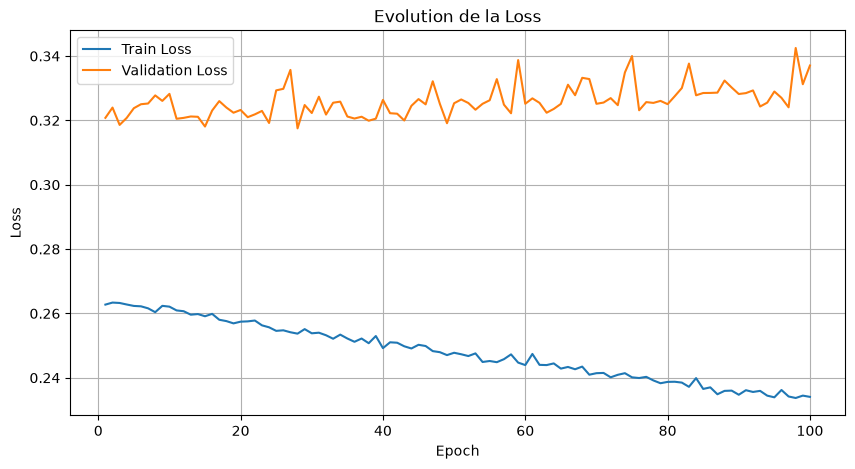

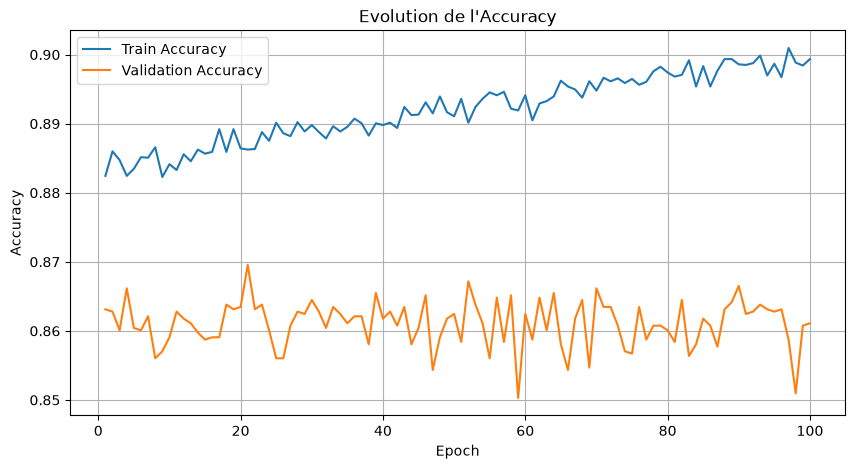

In [151]:
model_evolution_plot(history)

## Fine Tuning / Optimisation des hyperParamètres

Le modèle sera encapsulé dans une fonction permettant de passer en entrée les paramètres et donc de procéder a un *GRID SEARCH*

In [ ]:

## Creation d'un reseau de neuronnes customisé
class CustomNeuralNetwork(nn.Module):
    def __init__(self, nodes, drop_prb):
        super().__init__()

        #Création d'un sequential
        self.network = nn.Sequential(
            #Première couche 10 input -> 32 neurones
            nn.Linear(10, nodes),
            #Fonction d'activation ReLU
            nn.ReLU(),
            nn.Dropout(drop_prb),

            #Seconde couche 32 neurones -> 32 neurones
            nn.Linear(nodes, nodes),
            nn.ReLU(),

            #Dernière couche 32 neurones -> 1 output
            nn.Linear(nodes, 1),
            #Fonction d'activation sigmoid car output
            #nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

In [ ]:

# Creation de la fonction visant a entrainer un modèle selon les hyperparamètres sélectionnés
def train_model(nodes, drop_prb, learning_rate, batch_size, train_dataset = train_dataset, valid_dataset = valid_dataset, n_epoch = 100):

    print(
            f"Test des hyperparamètres suivants :"
            f"Nodes = {nodes}, "
            f"drop_prb={drop_prb:.1f}, "
            f"learning_rate={learning_rate:.5f}, "
            f"batch_size ={batch_size} "
        )

    ####################
    ##  DATA LOADERS  ##
    ####################
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    valid_loader = DataLoader(
        valid_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    ##########################
    ##  CREATION DU MODELE  ##
    ##########################
    nn_model = CustomNeuralNetwork(nodes, drop_prb)

    criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.Adam(
        nn_model.parameters(),
        lr=learning_rate
    )

    ##############################
    ##  OPTIMISATION DU MODELE  ##
    ##############################
    
    for epoch in range(n_epoch):

        # =====================
        # ENTRAINEMENT
        # =====================

        nn_model.train()

        train_loss = 0
        train_correct = 0
        train_total = 0

        for X_batch, y_batch in train_loader:

            optimizer.zero_grad()

            prediction = nn_model(X_batch)

            y_batch = y_batch.unsqueeze(1)
            loss = criterion(prediction, y_batch)

            loss.backward()

            optimizer.step()

            train_loss += loss.item()

            probability = torch.sigmoid(prediction)
            predicted_class = (probability >= 0.5).float()

            train_correct += (predicted_class == y_batch).sum().item()
            train_total += len(y_batch)
            #print(prediction)

        
        train_loss /= len(train_loader)
        train_accuracy = train_correct / train_total


        # =====================
        # VALIDATION
        # =====================

        nn_model.eval()

        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for X_batch, y_batch in valid_loader:

                prediction = nn_model(X_batch)

                y_batch = y_batch.unsqueeze(1)
                loss = criterion(prediction, y_batch)

                val_loss += loss.item()

                probability = torch.sigmoid(prediction)
                predicted_class = (probability >= 0.5).float()

                val_correct += (predicted_class == y_batch).sum().item()
                val_total += len(y_batch)


        val_loss /= len(valid_loader)
        val_accuracy = val_correct / val_total

        # Enregistrement des résultat par epoch
        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)

        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)


        return nn_model, history 

In [160]:
from itertools import product

nodes_list = [16, 32, 64]
dropout_list = [0, 0.2, 0.4]
learning_rates = [0.0001, 0.001, 0.01]
batch_sizes = [16, 32, 64]

results = []

for nodes, dropout, lr, batch_size in product(
    nodes_list,
    dropout_list,
    learning_rates,
    batch_sizes
):

    model, history = train_model(
        nodes,
        dropout,
        lr,
        batch_size
    )

    best_val_accuracy = max(history["val_accuracy"])

    results.append({
        "nodes": nodes,
        "dropout": dropout,
        "lr": lr,
        "batch_size": batch_size,
        "val_accuracy": best_val_accuracy,
        "model": model
    })

Test des hyperparamètres suivants :Nodes = 16, drop_prb=0.0, learning_rate=0.00010, batch_size =16 
Test des hyperparamètres suivants :Nodes = 16, drop_prb=0.0, learning_rate=0.00010, batch_size =32 
Test des hyperparamètres suivants :Nodes = 16, drop_prb=0.0, learning_rate=0.00010, batch_size =64 
Test des hyperparamètres suivants :Nodes = 16, drop_prb=0.0, learning_rate=0.00100, batch_size =16 
Test des hyperparamètres suivants :Nodes = 16, drop_prb=0.0, learning_rate=0.00100, batch_size =32 
Test des hyperparamètres suivants :Nodes = 16, drop_prb=0.0, learning_rate=0.00100, batch_size =64 
Test des hyperparamètres suivants :Nodes = 16, drop_prb=0.0, learning_rate=0.01000, batch_size =16 
Test des hyperparamètres suivants :Nodes = 16, drop_prb=0.0, learning_rate=0.01000, batch_size =32 
Test des hyperparamètres suivants :Nodes = 16, drop_prb=0.0, learning_rate=0.01000, batch_size =64 
Test des hyperparamètres suivants :Nodes = 16, drop_prb=0.2, learning_rate=0.00010, batch_size =16 


In [163]:
best_result = max(
    results,
    key=lambda x: x["val_accuracy"]
)

In [164]:
print(best_result)

{'nodes': 16, 'dropout': 0, 'lr': 0.0001, 'batch_size': 16, 'val_accuracy': 0.8695505238256168, 'model': CustomNeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0, inplace=False)
    (3): Linear(in_features=16, out_features=16, bias=True)
    (4): ReLU()
    (5): Linear(in_features=16, out_features=1, bias=True)
  )
)}
